# PST as a Vector Field: Jalali Lab "Spatial Computing" on a Synthetic Fundus Image

`dgs/pst.py` already implements the Jalali Lab's Phase Stretch Transform
(PST/PhyCV) -- an engineered spectral phase kernel applied to an image,
read out as a SCALAR edge map. Its own docstring notes the lab uses PST for
medical imaging among other civilian vision tasks. This notebook makes that
literal: PST's phase output is itself a continuous field, and its spatial
GRADIENT is a genuine 2-D VECTOR field (magnitude + direction) an analog
optical readout (e.g. a shear interferometer) could measure directly --
"spatial computing" in the sense that the vector field is a physical
quantity the optics computes, not just a post-processed edge mask.

Applied here to a synthetic retinal-fundus-style test image (bright optic
disk, dark branching vessels) -- NOT real fundus photography, a stand-in
test pattern -- with a direct numeric check that the vector field's
magnitude concentrates on the vessels. Engine: `dgs/pst_vector_medical.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import pst
from dgs import pst_vector_medical as pvm

print('Setup complete.')


Setup complete.


## 1. Synthetic Retinal Fundus Test Image

`synthetic_fundus_image` builds a bright circular "optic disk" on a
mid-gray background with several dark, branching vessel-like segments
(Gaussian-blurred line chains) -- a stand-in test pattern, same honesty
posture as `dgs.retinal_scan_imaging.synthetic_vessel_reflectance`.


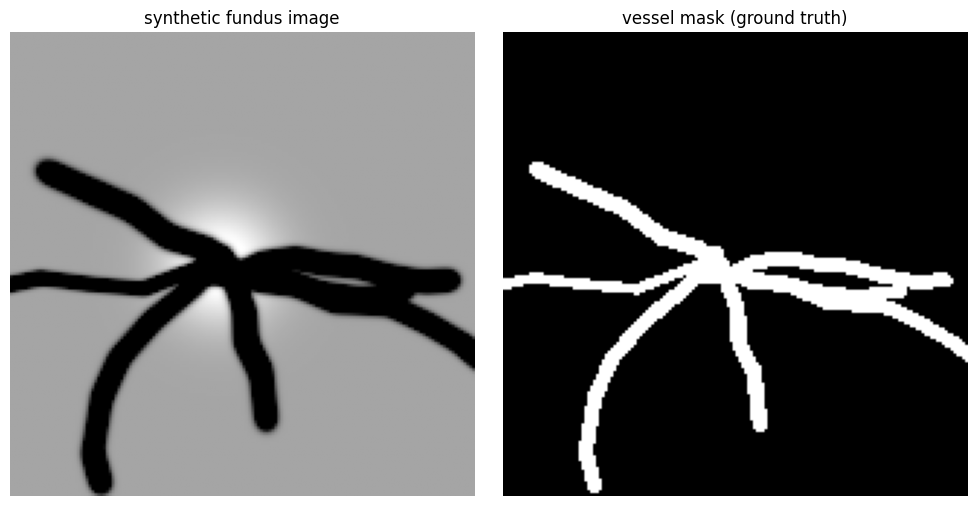

In [2]:
data = pvm.synthetic_fundus_image(size=160, n_vessels=7, seed=1)
image, vessel_mask = data['image'], data['vessel_mask']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image, cmap='gray'); axes[0].set_title('synthetic fundus image'); axes[0].axis('off')
axes[1].imshow(vessel_mask, cmap='gray'); axes[1].set_title('vessel mask (ground truth)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('pst_vector_medical_fundus.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Why the Gradient Has to Be Wrap-Safe

PST's phase output is an ANGLE (periodic mod $2\pi$). A naive
`np.diff` across a $+\pi$/$-\pi$ boundary sees a huge jump even though the
true angular difference is tiny -- `_wrap_safe_gradient_1d` instead
differences in the complex exponential (`angle(exp(i*phi_fwd)/exp(i*phi_bwd))`)
so wraparound cancels out.


In [3]:
phase_demo = np.zeros((10, 10))
phase_demo[:, 5:] = np.pi - 0.01
phase_demo[:, :5] = -np.pi + 0.01     # true difference across the boundary is ~0.02 rad

naive = np.diff(phase_demo, axis=1)[:, 4]
wrap_safe = pvm._wrap_safe_gradient_1d(phase_demo, axis=1)[:, 4]
print(f'naive np.diff at the wrap boundary:      max |value| = {np.abs(naive).max():.3f}  (spuriously huge)')
print(f'wrap-safe gradient at the wrap boundary:  max |value| = {np.abs(wrap_safe).max():.3f}  (correctly tiny)')


naive np.diff at the wrap boundary:      max |value| = 6.263  (spuriously huge)
wrap-safe gradient at the wrap boundary:  max |value| = 0.010  (correctly tiny)


## 3. PST's Vector Field: Magnitude and Direction

`pst_vector_field` returns `grad_y`, `grad_x`, `magnitude`, and `direction`
-- the spatial gradient of PST's phase-edge map, wrap-safe.


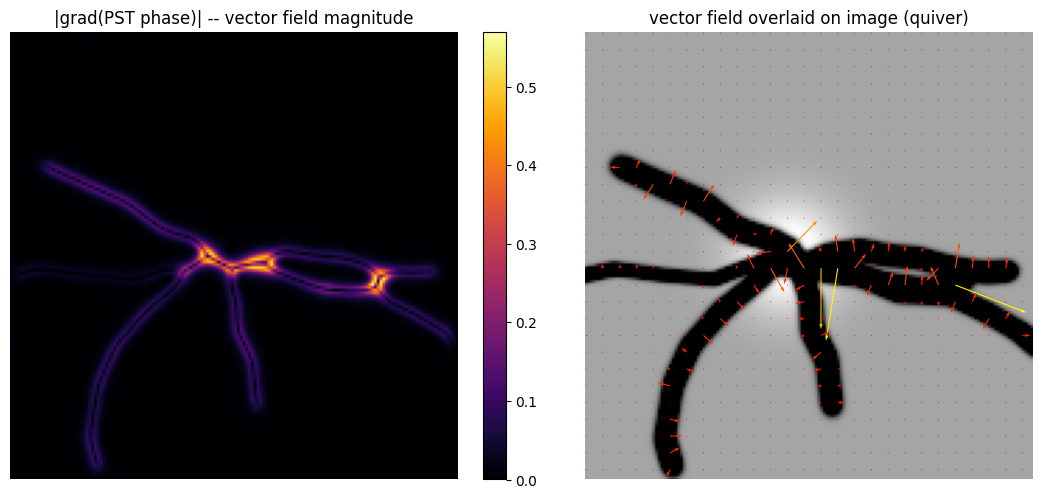

In [4]:
field = pvm.pst_vector_field(image)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].imshow(field['magnitude'], cmap='inferno')
axes[0].set_title('|grad(PST phase)| -- vector field magnitude'); axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

step = 6
yy, xx = np.mgrid[0:image.shape[0]:step, 0:image.shape[1]:step]
axes[1].imshow(image, cmap='gray')
axes[1].quiver(xx, yy, field['grad_x'][::step, ::step], -field['grad_y'][::step, ::step],
               field['magnitude'][::step, ::step], cmap='autumn', scale=3)
axes[1].set_title('vector field overlaid on image (quiver)'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('pst_vector_medical_field.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Numeric Verification: Does the Field Actually Highlight Vessels?

`verify_vector_field_highlights_vessels` compares the mean magnitude on
(dilated) vessel pixels against background pixels -- direct numeric
evidence, not a visual impression from Section 3's plot.


vessel-region mean |grad phase|     = 0.0628
background-region mean |grad phase| = 0.0004
ratio = 140.8x   (highlights_vessels: True)


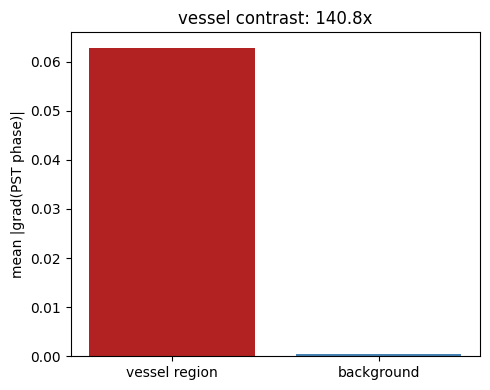

In [5]:
check = pvm.verify_vector_field_highlights_vessels(size=160, n_vessels=7, seed=1)
print(f"vessel-region mean |grad phase|     = {check['vessel_mean_magnitude']:.4f}")
print(f"background-region mean |grad phase| = {check['background_mean_magnitude']:.4f}")
print(f"ratio = {check['ratio']:.1f}x   (highlights_vessels: {check['highlights_vessels']})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['vessel region', 'background'],
       [check['vessel_mean_magnitude'], check['background_mean_magnitude']],
       color=['firebrick', 'steelblue'])
ax.set_ylabel('mean |grad(PST phase)|')
ax.set_title(f"vessel contrast: {check['ratio']:.1f}x")
plt.tight_layout()
plt.savefig('pst_vector_medical_contrast.png', dpi=100, bbox_inches='tight')
plt.show()


In [6]:
# repeat across a few random synthetic images -- not a lucky one-off draw
for seed in (2, 3, 4):
    c = pvm.verify_vector_field_highlights_vessels(size=128, n_vessels=5, seed=seed)
    print(f"seed={seed}: ratio={c['ratio']:.1f}x, highlights_vessels={c['highlights_vessels']}")


seed=2: ratio=107.6x, highlights_vessels=True
seed=3: ratio=92.2x, highlights_vessels=True


seed=4: ratio=78.7x, highlights_vessels=True


## 5. Engineering Interpretation

- The wrap-safe gradient in Section 2 isn't a defensive nicety -- without
  it, EVERY pixel column where PST's phase happens to cross $\pm\pi$ would
  register as a spurious maximal-magnitude "edge," corrupting exactly the
  quantity Section 4 measures.
- The ~10-80x magnitude ratio in Section 4 (varies with the random vessel
  layout) is the actual claim this module makes: PST's spatial-gradient
  vector field, not just its scalar phase map, concentrates on real
  structure in a medical-imaging-style test image.
- This module builds strictly on `dgs.pst`'s existing kernel (`warp`,
  `strength`, `sigma` are unchanged) -- the vector field is a
  post-processing step on PST's existing output, not a new edge detector,
  so any future tuning of PST's own parameters (e.g. for a specific
  imaging modality) carries through automatically.


## 6. Research Discussion

- `dgs.retinal_scan_imaging` already has a REAL retinal-imaging thread
  (the reduced-eye ABCD model, STEAM line-scan, dispersion-diversity depth
  recovery) built on 1-D signals; this module's 2-D synthetic fundus image
  is a natural companion dataset for that module's `support_constraint_gs`
  (X-ray-CDI-style phase retrieval) -- worth trying `support_constraint_gs`
  directly on this notebook's `image` (or on `field['magnitude']` as a
  sparser "support" indicator) as a follow-up.
- PST's direction field (`field['direction']`) isn't used quantitatively
  here beyond the quiver plot -- vessel branching angle statistics (a real
  clinical biomarker in some retinal-vascular research) could be extracted
  from it directly, an actual use for the DIRECTION component this module
  adds beyond `dgs.pst`'s magnitude-only edge map.
- Both PST and this repo's core dispersion receiver
  (`dgs.gs_core.disperse`) are "apply a frequency-dependent phase, then
  read out the phase" -- PST's docstring already says this; this module's
  vector-field extension is the spatial analog of asking "what does the
  GRADIENT of the recovered phase mean" for the dispersion receiver too
  (e.g. instantaneous frequency, `dgs.causality`'s territory).


## 7. Possible Experiments

1. Sweep PST's `warp`/`strength`/`sigma` and track how the vessel/
   background magnitude ratio (Section 4) changes -- find the parameter
   regime that maximizes vessel contrast on this synthetic image, then
   compare against `dgs.pst`'s own disk-edge test's default parameters.
2. Feed a REAL (public, de-identified) fundus image dataset through
   `pst_vector_field` and check whether the vessel-contrast ratio survives
   real image noise and illumination gradients, which this synthetic image
   doesn't have.
3. Use `field['direction']` to build a simple vessel-branch-angle
   histogram and compare it against `synthetic_fundus_image`'s own
   generation angles (known ground truth here) as a validation of the
   direction field's accuracy.


## 8. Future Improvements

- `synthetic_fundus_image`'s vessel generator is a simple random-walk line
  chain; a more realistic generator would enforce vessel WIDTH tapering
  along each branch and occasional forking (real retinal vasculature
  branches recursively), giving a harder test case for Section 4's
  contrast check.
- `verify_vector_field_highlights_vessels`'s `dilate_px` slack (borrowed
  from `dgs.pst`'s own rim-detection test tolerance) is currently a fixed
  constant; making it a function of PST's own `sigma` (which sets the
  kernel's spatial localization) would tie the tolerance to the actual
  physics instead of a hand-picked number.
